In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv",
    engine="python"
)

print(df.shape)
print(df.columns.tolist())
df.head()

(8173, 46)
['id', 'event_type', 'latitude', 'longitude', 'endlatitude', 'endlongitude', 'address', 'end_address', 'event_cause', 'requires_road_closure', 'start_datetime', 'end_datetime', 'status', 'authenticated', 'modified_datetime', 'map_file', 'direction', 'description', 'veh_type', 'veh_no', 'corridor', 'priority', 'cargo_material', 'reason_breakdown', 'age_of_truck', 'created_date', 'route_path', 'client_id', 'created_by_id', 'last_modified_by_id', 'assigned_to_police_id', 'citizen_accident_id', 'comment', 'police_station', 'meta_data', 'kgid', 'resolved_at_address', 'resolved_at_latitude', 'resolved_at_longitude', 'closed_by_id', 'closed_datetime', 'resolved_by_id', 'resolved_datetime', 'gba_identifier', 'zone', 'junction']


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8173 entries, 0 to 8172
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     8173 non-null   object 
 1   event_type             8173 non-null   object 
 2   latitude               8173 non-null   float64
 3   longitude              8173 non-null   float64
 4   endlatitude            8004 non-null   float64
 5   endlongitude           8004 non-null   float64
 6   address                8170 non-null   object 
 7   end_address            687 non-null    object 
 8   event_cause            8173 non-null   object 
 9   requires_road_closure  8173 non-null   bool   
 10  start_datetime         8173 non-null   object 
 11  end_datetime           490 non-null    object 
 12  status                 8173 non-null   object 
 13  authenticated          8173 non-null   object 
 14  modified_datetime      8173 non-null   object 
 15  map_

In [ ]:
!pip install folium scikit-learn plotly -q

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv to Astram event data_anonymized - Astram event data_anonymizedb40ac87 (1).csv


In [ ]:
import pandas as pd
import numpy as np

file_name = list(uploaded.keys())[0]

df = pd.read_csv(
    file_name,
    engine="python",
    on_bad_lines="skip"
)

print(df.shape)
df.head()

(8173, 46)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


In [ ]:
cols = [
    'event_type',
    'event_cause',
    'requires_road_closure',
    'start_datetime',
    'end_datetime',
    'priority',
    'corridor',
    'police_station',
    'zone',
    'junction',
    'latitude',
    'longitude'
]

df = df[cols].copy()

In [ ]:
df['start_datetime'] = pd.to_datetime(
    df['start_datetime'],
    errors='coerce'
)

df['end_datetime'] = pd.to_datetime(
    df['end_datetime'],
    errors='coerce'
)

In [ ]:
df['duration_minutes'] = (
    df['end_datetime'] -
    df['start_datetime']
).dt.total_seconds() / 60

median_duration = df['duration_minutes'].median()

df['duration_minutes'] = (
    df['duration_minutes']
    .fillna(median_duration)
)

In [ ]:
priority_map = {
    'LOW':0,
    'HIGH':1
}

df['priority_score'] = (
    df['priority']
    .astype(str)
    .str.upper()
    .map(priority_map)
)

df['priority_score'] = (
    df['priority_score']
    .fillna(0)
)

In [ ]:
junction_stats = pd.DataFrame()

junction_stats['incident_count'] = (
    df.groupby('junction')
    .size()
)

junction_stats['high_priority_ratio'] = (
    df.groupby('junction')['priority_score']
    .mean()
)

junction_stats['road_closure_ratio'] = (
    df.groupby('junction')[
        'requires_road_closure'
    ].mean()
)

junction_stats['planned_event_ratio'] = (
    df.groupby('junction')['event_type']
    .apply(
        lambda x:
        (x=='planned').mean()
    )
)

junction_stats['unique_causes'] = (
    df.groupby('junction')['event_cause']
    .nunique()
)

junction_stats = junction_stats.fillna(0)

junction_stats.head()

,incident_count,high_priority_ratio,road_closure_ratio,planned_event_ratio,unique_causes
junction,,,,,
17th Mn 1st Crs Aishwarya Stores Jn,1,0.000000,0.000000,0.000000,1
27th Cross Jayanagar(Ganapathi Temple),1,0.000000,0.000000,0.000000,1
28thMainJayanagarJunc,6,0.166667,0.000000,0.000000,1
29thMainRdBTM LayoutJunc,5,0.000000,0.000000,0.000000,3
5thMainHSR,3,1.000000,0.333333,0.333333,3


In [ ]:
print(
    junction_stats.describe()
)

       incident_count  high_priority_ratio  road_closure_ratio  \
count      294.000000           294.000000          294.000000   
mean         8.537415             0.558860            0.109498   
std          8.933025             0.481350            0.212825   
min          1.000000             0.000000            0.000000   
25%          3.000000             0.000000            0.000000   
50%          6.000000             0.919872            0.000000   
75%         11.000000             1.000000            0.142857   
max         64.000000             1.000000            1.000000   

       planned_event_ratio  unique_causes  
count           294.000000     294.000000  
mean              0.064091       2.377551  
std               0.164042       1.333593  
min               0.000000       1.000000  
25%               0.000000       1.000000  
50%               0.000000       2.000000  
75%               0.000000       3.000000  
max               1.000000       7.000000  


In [ ]:
from sklearn.preprocessing import StandardScaler

risk_features = [
    'incident_count',
    'high_priority_ratio',
    'road_closure_ratio',
    'planned_event_ratio',
    'unique_causes'
]

scaler = StandardScaler()

X = scaler.fit_transform(
    junction_stats[risk_features]
)

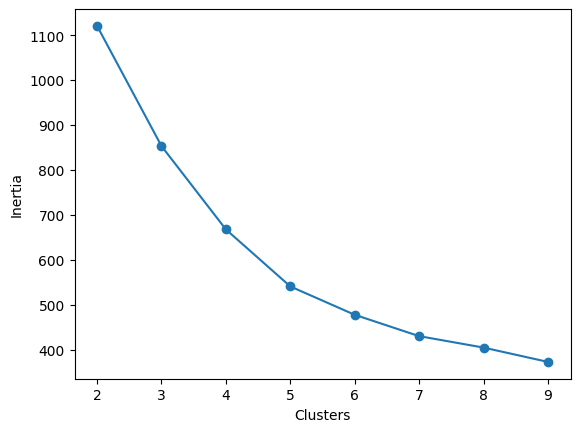

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,10):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(X)

    inertia.append(km.inertia_)

plt.plot(
    range(2,10),
    inertia,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

junction_stats['cluster'] = (
    kmeans.fit_predict(X)
)

In [ ]:
cluster_rank = (
    junction_stats
    .groupby('cluster')
    ['incident_count']
    .mean()
    .sort_values()
    .index
)

In [ ]:
risk_map = {
    cluster_rank[0]:"Low",
    cluster_rank[1]:"Medium",
    cluster_rank[2]:"High",
    cluster_rank[3]:"Critical"
}

junction_stats['risk_level'] = (
    junction_stats['cluster']
    .map(risk_map)
)

In [ ]:
print(
    junction_stats['risk_level']
    .value_counts()
)

risk_level
High        115
Medium      109
Critical     51
Low          19
Name: count, dtype: int64


In [ ]:
critical = junction_stats[
    junction_stats['risk_level']
    == 'Critical'
]

critical.sort_values(
    'incident_count',
    ascending=False
).head(20)

,incident_count,high_priority_ratio,road_closure_ratio,planned_event_ratio,unique_causes,cluster,risk_level
junction,,,,,,,
MekhriCircle,64,0.984375,0.015625,0.000000,4,1,Critical
AyyappaTempleJunc,49,0.979592,0.020408,0.000000,3,1,Critical
SatteliteBusStandJunc,43,0.976744,0.023256,0.000000,2,1,Critical
YeshwanthpuraCircle,38,0.947368,0.026316,0.000000,5,1,Critical
YelhankaCircle,34,0.911765,0.000000,0.058824,6,1,Critical
toll gate mysore road,33,0.969697,0.060606,0.000000,3,1,Critical
SilkBoardJunc,33,1.000000,0.121212,0.030303,6,1,Critical
JalahalliCross(SM Circle),32,1.000000,0.000000,0.000000,3,1,Critical
Nagavara-ORR Junction,32,1.000000,0.062500,0.156250,6,1,Critical


In [ ]:
df = df.merge(
    junction_stats[
        ['risk_level']
    ],
    left_on='junction',
    right_index=True,
    how='left'
)

In [ ]:
heatmap_df = (
    df.groupby('junction')
    .agg({
        'latitude':'mean',
        'longitude':'mean',
        'risk_level':'first'
    })
)

heatmap_df.head()

,latitude,longitude,risk_level
junction,,,
17th Mn 1st Crs Aishwarya Stores Jn,12.925044,77.633626,Medium
27th Cross Jayanagar(Ganapathi Temple),12.931752,77.579739,Medium
28thMainJayanagarJunc,12.916833,77.595374,Medium
29thMainRdBTM LayoutJunc,12.916210,77.616143,Medium
5thMainHSR,12.916451,77.631317,Low


In [ ]:
import folium

m = folium.Map(
    location=[
        df['latitude'].mean(),
        df['longitude'].mean()
    ],
    zoom_start=11
)

color_map = {
    'Low':'green',
    'Medium':'yellow',
    'High':'orange',
    'Critical':'red'
}

for idx,row in heatmap_df.iterrows():

    folium.CircleMarker(
        location=[
            row['latitude'],
            row['longitude']
        ],
        radius=6,
        color=color_map[
            row['risk_level']
        ],
        fill=True,
        popup=f"""
        {idx}
        <br>
        Risk:
        {row['risk_level']}
        """
    ).add_to(m)

m

In [ ]:
import joblib

joblib.dump(
    kmeans,
    "junction_risk_model.pkl"
)

joblib.dump(
    scaler,
    "risk_scaler.pkl"
)

junction_stats.to_csv(
    "junction_risk_table.csv"
)

In [ ]:
import zipfile

with zipfile.ZipFile("module1_outputs.zip", "w") as zipf:
    zipf.write("junction_risk_model.pkl")
    zipf.write("risk_scaler.pkl")
    zipf.write("junction_risk_table.csv")

In [ ]:
from google.colab import files

files.download("module1_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(junction_stats['risk_level'].value_counts())

risk_level
High        115
Medium      109
Critical     51
Low          19
Name: count, dtype: int64


In [ ]:
critical = junction_stats[
    junction_stats['risk_level']=="Critical"
]

critical.sort_values(
    "incident_count",
    ascending=False
).head(20)

,incident_count,high_priority_ratio,road_closure_ratio,planned_event_ratio,unique_causes,cluster,risk_level
junction,,,,,,,
MekhriCircle,64,0.984375,0.015625,0.000000,4,1,Critical
AyyappaTempleJunc,49,0.979592,0.020408,0.000000,3,1,Critical
SatteliteBusStandJunc,43,0.976744,0.023256,0.000000,2,1,Critical
YeshwanthpuraCircle,38,0.947368,0.026316,0.000000,5,1,Critical
YelhankaCircle,34,0.911765,0.000000,0.058824,6,1,Critical
toll gate mysore road,33,0.969697,0.060606,0.000000,3,1,Critical
SilkBoardJunc,33,1.000000,0.121212,0.030303,6,1,Critical
JalahalliCross(SM Circle),32,1.000000,0.000000,0.000000,3,1,Critical
Nagavara-ORR Junction,32,1.000000,0.062500,0.156250,6,1,Critical


In [ ]:
m.save("risk_heatmap.html")

In [ ]:
critical = junction_stats[
    junction_stats['risk_level']=="Critical"
]

critical.sort_values(
    "incident_count",
    ascending=False
).head(20)

,incident_count,high_priority_ratio,road_closure_ratio,planned_event_ratio,unique_causes,cluster,risk_level
junction,,,,,,,
MekhriCircle,64,0.984375,0.015625,0.000000,4,1,Critical
AyyappaTempleJunc,49,0.979592,0.020408,0.000000,3,1,Critical
SatteliteBusStandJunc,43,0.976744,0.023256,0.000000,2,1,Critical
YeshwanthpuraCircle,38,0.947368,0.026316,0.000000,5,1,Critical
YelhankaCircle,34,0.911765,0.000000,0.058824,6,1,Critical
toll gate mysore road,33,0.969697,0.060606,0.000000,3,1,Critical
SilkBoardJunc,33,1.000000,0.121212,0.030303,6,1,Critical
JalahalliCross(SM Circle),32,1.000000,0.000000,0.000000,3,1,Critical
Nagavara-ORR Junction,32,1.000000,0.062500,0.156250,6,1,Critical


In [ ]:
critical.to_csv(
    "critical_junctions.csv"
)